# 05 — LSTM Agent **v4**: OHLCV-only + larger stack

Wejście do sieci to **wyłącznie surowe OHLCV** (5 liczb na godzinę), standaryzowane statystykami z traina — **bez** `make_features` / `FEATURE_COLS`.
Architektura: głębszy LSTM + szerszy MLP na ostatniej chwili czasu. Reszta (split kalendarzowy, etykieta następnej świecy, backtest — te same reguły co w v3) bez zmian.


In [1]:
# ── Configuration — v4 (edit here) ─────────────────────────────────────────
SYMBOL        = 'BTCUSDT'
INTERVAL      = '1h'

OHLCV_COLS    = ["open", "high", "low", "close", "volume"]  # jedyna macierz cech

TRAIN_END     = '2024-06-01'
VAL_END       = '2024-11-10'
TEST_START    = '2024-11-10'

SEQ_LEN       = 168            # 7 dni × 1h

# Większy model (v3: 64 ukryte × 2 warstwy + głowa 64→32→1)
LSTM_UNITS    = 192            # hidden size
NUM_LAYERS    = 3
DROPOUT       = 0.35
EPOCHS        = 60
BATCH_SIZE    = 256
LR            = 1e-3
WEIGHT_DECAY  = 1e-5           # lżejsza regularyzacja niż v3 przy większej sieci
PATIENCE      = 12

# Trading (jak v3)
CONFIDENCE_THRESHOLD = 0.56
EXIT_THRESHOLD       = 0.48
MIN_HOLD_CANDLES     = 2
MAX_HOLD_CANDLES     = 24
COOLDOWN_CANDLES     = 6
TAKE_PROFIT          = 0.03
STOP_LOSS            = 0.02
FEE                  = 0.0005

# Strojenie liczby transakcji: CONFIDENCE_THRESHOLD (np. 0.54–0.58), potem COOLDOWN.

SEED = 42


In [2]:
import random
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from hmats.data.binance_store import load
# v4: brak engineered features — tylko OHLCV z klines
from hmats.data.splits import calendar_split

warnings.filterwarnings('ignore')
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available() and torch.backends.mps.is_built():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}')

mpl.rcParams.update({
    'font.family': 'serif', 'font.serif': ['DejaVu Serif'],
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 10, 'axes.titlesize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 9, 'legend.framealpha': 0.85,
    'figure.dpi': 120, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})
ACCENT='#F7931A'; BLUE='#2962FF'; GREY='#9E9E9E'; RED='#EF5350'; GREEN='#26A69A'

REPO_ROOT = Path.cwd().parents[2]
if not (REPO_ROOT / 'pyproject.toml').exists():
    REPO_ROOT = Path.cwd()
RAW_DIR     = REPO_ROOT / 'data' / 'raw'
MODELS_DIR  = REPO_ROOT / 'models'
FIGURES_DIR = REPO_ROOT / 'figures'
MODELS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)


Device: mps


## 1. Load & prepare data

In [3]:
raw = load(SYMBOL, INTERVAL, store_dir=str(RAW_DIR))
raw.index = raw.index.tz_localize(None) if raw.index.tz else raw.index

missing = [c for c in OHLCV_COLS if c not in raw.columns]
if missing:
    raise ValueError(f"Brak kolumn OHLCV w danych: {missing}")

feat_df = raw[OHLCV_COLS].astype(np.float64).copy()
feat_df['label'] = (feat_df['close'].shift(-1) > feat_df['close']).astype(np.float32)
feat_df = feat_df.replace([np.inf, -np.inf], np.nan).dropna()

train_df, val_df, test_df = calendar_split(feat_df, train_end=TRAIN_END, val_end=VAL_END)

print(f'Train: {len(train_df):>7,} rows  {train_df.index.min().date()} → {train_df.index.max().date()}')
print(f'Val:   {len(val_df):>7,} rows  {val_df.index.min().date()} → {val_df.index.max().date()}')
print(f'Test:  {len(test_df):>7,} rows  {test_df.index.min().date()} → {test_df.index.max().date()}')
print(f'Label balance — train: {train_df["label"].mean():.3f}  val: {val_df["label"].mean():.3f}  test: {test_df["label"].mean():.3f}')
print('Input: surowe OHLCV (5 kanałów), standaryzacja z traina.')


Train:  59,389 rows  2017-08-17 → 2024-06-01
Val:     3,888 rows  2024-06-01 → 2024-11-10
Test:   12,960 rows  2024-11-10 → 2026-05-04
Label balance — train: 0.510  val: 0.505  test: 0.504
Input: surowe OHLCV (5 kanałów), standaryzacja z traina.


## 2. Normalisation & sequences

Każdy kanał OHLCV jest **osobno** standaryzowany (`mu`/`sd` z traina). Val/test używają tych samych statystyk — brak wycieku.

In [4]:
X_cols = OHLCV_COLS
mu = train_df[X_cols].mean().values.astype(np.float32)
sd = (train_df[X_cols].std().values + 1e-8).astype(np.float32)
np.savez(MODELS_DIR / 'lstm_scaler_v4.npz', mu=mu, sd=sd)

def make_sequences(df, seq_len=SEQ_LEN):
    X_raw = ((df[X_cols].values - mu) / sd).astype(np.float32)
    y_raw = df['label'].values.astype(np.float32)
    Xs, ys = [], []
    for i in range(seq_len, len(X_raw)):
        Xs.append(X_raw[i - seq_len : i])
        ys.append(y_raw[i])
    return np.array(Xs), np.array(ys)

X_train, y_train = make_sequences(train_df)
X_val,   y_val   = make_sequences(val_df)
X_test,  y_test  = make_sequences(test_df)

print(f'X_train: {X_train.shape}  X_val: {X_val.shape}  X_test: {X_test.shape}  (timesteps × {len(X_cols)} OHLCV)')


X_train: (59221, 168, 5)  X_val: (3720, 168, 5)  X_test: (12792, 168, 5)  (timesteps × 5 OHLCV)


## 3. Model (v4)

`LSTMClassifierV4`: **3** warstwy LSTM (`hidden=192`, dropout między warstwami), **LayerNorm** na wektorze ostatniej chwili, głowa **192 → 128 → 64 → 1** + sigmoid (`P(up)`).


In [5]:
class LSTMClassifierV4(nn.Module):
    """LSTM on raw OHLCV sequences + deeper classifier head."""

    def __init__(self, input_dim: int, hidden_dim: int, num_layers: int, dropout: float):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.5),
            nn.Linear(64, 1),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out, _ = self.lstm(x)
        out = self.norm(out[:, -1])
        out = self.dropout(out)
        return self.head(out).squeeze(-1)


model = LSTMClassifierV4(
    input_dim=len(OHLCV_COLS),
    hidden_dim=LSTM_UNITS,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
).to(DEVICE)

print(model)
print(f'Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')


LSTMClassifierV4(
  (lstm): LSTM(5, 192, num_layers=3, batch_first=True, dropout=0.35)
  (norm): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.35, inplace=False)
  (head): Sequential(
    (0): Linear(in_features=192, out_features=128, bias=True)
    (1): ReLU(inplace=True)
    (2): Dropout(p=0.35, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU(inplace=True)
    (5): Dropout(p=0.175, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
    (7): Sigmoid()
  )
)
Parameters: 779,137


## 4. Training with early stopping

Validation loss is tracked each epoch. If it does not improve for `PATIENCE` epochs the best checkpoint is restored and training stops.

In [6]:
train_ds     = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
val_ds       = TensorDataset(torch.from_numpy(X_val),   torch.from_numpy(y_val))
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss   = float('inf')
patience_count  = 0
best_state      = None
stopped_epoch   = EPOCHS

for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    model.train()
    t_loss, t_correct, t_total = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        preds = model(xb)
        loss  = criterion(preds, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        t_loss    += loss.item() * len(xb)
        t_correct += ((preds > 0.5) == yb.bool()).sum().item()
        t_total   += len(xb)

    # ── Validate ──
    model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            preds   = model(xb)
            v_loss    += criterion(preds, yb).item() * len(xb)
            v_correct += ((preds > 0.5) == yb.bool()).sum().item()
            v_total   += len(xb)

    avg_t_loss = t_loss / t_total
    avg_v_loss = v_loss / v_total
    t_acc = t_correct / t_total
    v_acc = v_correct / v_total

    history['train_loss'].append(avg_t_loss)
    history['val_loss'].append(avg_v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)

    scheduler.step(avg_v_loss)

    # ── Early stopping ──
    if avg_v_loss < best_val_loss:
        best_val_loss  = avg_v_loss
        best_state     = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            stopped_epoch = epoch
            print(f'Early stopping at epoch {epoch} (best val loss: {best_val_loss:.4f})')
            break

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:>3}/{EPOCHS}  '
              f'train_loss={avg_t_loss:.4f}  val_loss={avg_v_loss:.4f}  '
              f'train_acc={t_acc:.4f}  val_acc={v_acc:.4f}')

# Restore best checkpoint
model.load_state_dict(best_state)
torch.save(model.state_dict(), MODELS_DIR / 'lstm_model_v4.pt')
print(f'Best model restored and saved (val_loss={best_val_loss:.4f})')


Epoch   1/60  train_loss=0.6941  val_loss=0.6933  train_acc=0.5027  val_acc=0.4962
Epoch   5/60  train_loss=0.6932  val_loss=0.6931  train_acc=0.5055  val_acc=0.5038
Epoch  10/60  train_loss=0.6930  val_loss=0.6931  train_acc=0.5102  val_acc=0.5038
Early stopping at epoch 14 (best val loss: 0.6931)
Best model restored and saved (val_loss=0.6931)


### Training curves (v4)

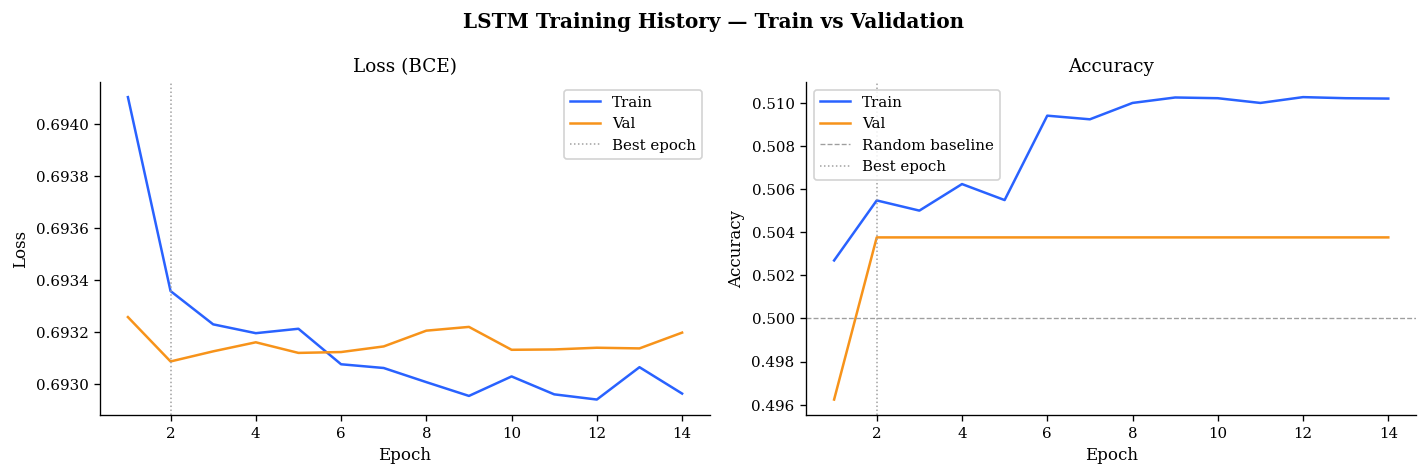

Final train acc: 0.5102
Final val acc:   0.5038
Overfitting gap: 0.0064  (acceptable)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_ran = range(1, len(history['train_loss']) + 1)

ax = axes[0]
ax.plot(epochs_ran, history['train_loss'], color=BLUE,  lw=1.5, label='Train')
ax.plot(epochs_ran, history['val_loss'],   color=ACCENT, lw=1.5, label='Val')
ax.axvline(stopped_epoch - PATIENCE, color=GREY, ls=':', lw=0.9, label='Best epoch')
ax.set_title('Loss (BCE)'); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend()

ax = axes[1]
ax.plot(epochs_ran, history['train_acc'], color=BLUE,   lw=1.5, label='Train')
ax.plot(epochs_ran, history['val_acc'],   color=ACCENT, lw=1.5, label='Val')
ax.axhline(0.5, color=GREY, ls='--', lw=0.8, label='Random baseline')
ax.axvline(stopped_epoch - PATIENCE, color=GREY, ls=':', lw=0.9, label='Best epoch')
ax.set_title('Accuracy'); ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.legend()

fig.suptitle('LSTM Training History — Train vs Validation', fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'lstm_training_history_v4.png')
plt.show()

gap = history['train_acc'][-1] - history['val_acc'][-1]
print(f'Final train acc: {history["train_acc"][-1]:.4f}')
print(f'Final val acc:   {history["val_acc"][-1]:.4f}')
print(f'Overfitting gap: {gap:.4f}  {"(acceptable)" if gap < 0.05 else "(overfitting — consider more dropout)"}')


## 5. Test-set evaluation

In [8]:
model.eval()
with torch.no_grad():
    X_t   = torch.from_numpy(X_test).to(DEVICE)
    probs = model(X_t).cpu().numpy()

signal_index = test_df.index[SEQ_LEN:]
close_prices = test_df['close'].values[SEQ_LEN:]

test_acc = ((probs > 0.5) == y_test).mean()
val_acc_final = history['val_acc'][stopped_epoch - PATIENCE - 1]
print(f'Val  accuracy (best epoch): {val_acc_final:.4f}')
print(f'Test accuracy:              {test_acc:.4f}')
print(f'Signals above entry threshold ({CONFIDENCE_THRESHOLD}): '
      f'{(probs >= CONFIDENCE_THRESHOLD).sum():,} / {len(probs):,}')


Val  accuracy (best epoch): 0.5038
Test accuracy:              0.4966
Signals above entry threshold (0.56): 0 / 12,792


## 6. Backtest

**Wejście:** `P(up)` ≥ `CONFIDENCE_THRESHOLD`, brak pozycji, koniec cooldownu.

**Wyjście (kolejność):**
1. Stop-loss (`STOP_LOSS`)
2. Take-profit (`TAKE_PROFIT`)
3. **Limit czasu:** w pozycji ≥ `MAX_HOLD_CANDLES` godzin (interwał 1h ⇒ liczba świec)
4. **Pewność:** `P(up)` < `EXIT_THRESHOLD` **oraz** w pozycji ≥ `MIN_HOLD_CANDLES` godzin

SL/TP działają od pierwszej świecy po wejściu (bez minimalnego holdu), tak jak w v3.


In [9]:
equity      = 1.0
cash        = 1.0
units       = 0.0
in_pos      = False
entry_px    = 0.0
entry_ts    = None
hold_count  = 0
cooldown    = 0

equity_curve = [equity]
trade_log    = []

for i, (ts, px, conf) in enumerate(zip(signal_index, close_prices, probs)):
    if cooldown > 0:
        cooldown -= 1

    if in_pos:
        hold_count += 1
        pnl_pct = (px - entry_px) / entry_px
        reason  = None

        if pnl_pct <= -STOP_LOSS:
            reason = 'sl'
        elif pnl_pct >= TAKE_PROFIT:
            reason = 'tp'
        elif hold_count >= MAX_HOLD_CANDLES:
            reason = 'max_hold'
        elif hold_count >= MIN_HOLD_CANDLES and conf < EXIT_THRESHOLD:
            reason = 'conf'

        if reason:
            proceeds = units * px * (1 - FEE)
            trade_log.append({
                'entry_time': entry_ts, 'exit_time': ts,
                'entry_px':   entry_px, 'exit_px':  px,
                'pnl_pct':    pnl_pct,  'reason':   reason,
                'hold_h':     hold_count,
            })
            cash       = proceeds
            units      = 0.0
            in_pos     = False
            hold_count = 0
            cooldown   = COOLDOWN_CANDLES

    if not in_pos and cooldown == 0 and conf >= CONFIDENCE_THRESHOLD:
        spend    = cash * (1 - FEE)
        units    = spend / px
        cash     = 0.0
        in_pos   = True
        entry_px = px
        entry_ts = ts
        hold_count = 0

    equity_curve.append(cash + units * px)

if in_pos:
    px = close_prices[-1]
    proceeds = units * px * (1 - FEE)
    trade_log.append({
        'entry_time': entry_ts, 'exit_time': signal_index[-1],
        'entry_px': entry_px,   'exit_px': px,
        'pnl_pct': (px - entry_px) / entry_px,
        'reason': 'eod', 'hold_h': hold_count,
    })
    equity_curve[-1] = proceeds

equity_arr = np.array(equity_curve[1:])
trades_df  = pd.DataFrame(trade_log)
print(f'Total trades: {len(trades_df)}')
if not trades_df.empty:
    print(trades_df['reason'].value_counts().to_string())
    print(f'Avg holding time:    {trades_df["hold_h"].mean():.1f}h')
    print(f'Median holding time: {trades_df["hold_h"].median():.1f}h')


Total trades: 0


## 7. Buy-and-hold benchmark

In [10]:
bh_units  = (1.0 * (1 - FEE)) / close_prices[0]
bh_equity = bh_units * close_prices
bh_final  = bh_units * close_prices[-1] * (1 - FEE)


## 8. Metrics

In [11]:
def sharpe(returns, ann_factor=24*365):
    """Annualised Sharpe on per-step log returns; undefined if returns are ~constant."""
    r = np.asarray(returns, dtype=np.float64)
    if len(r) < 2:
        return 0.0
    sd = float(np.std(r, ddof=1))
    if not np.isfinite(sd) or sd < 1e-15:
        return 0.0
    return float((r.mean() / sd) * np.sqrt(ann_factor))

def max_dd(equity):
    eq   = np.asarray(equity, dtype=np.float64)
    peak = np.maximum.accumulate(eq)
    return float(((eq - peak) / (peak + 1e-12)).min())

def log_rets(equity):
    eq = np.asarray(equity, dtype=np.float64)
    prev = np.maximum(eq[:-1], 1e-12)
    return np.log(eq[1:] / prev)

metrics = pd.DataFrame([
    {
        'Strategy':      'LSTM Agent',
        'Total Return':  f'{(equity_arr[-1] - 1) * 100:.2f}%',
        'Sharpe (ann.)': f'{sharpe(log_rets(equity_arr)):.3f}',
        'Max Drawdown':  f'{max_dd(equity_arr) * 100:.2f}%',
        'Num Trades':    len(trades_df),
        'Win Rate':      f'{(trades_df["pnl_pct"] > 0).mean() * 100:.1f}%' if not trades_df.empty else 'N/A',
        'Avg Hold (h)':  f'{trades_df["hold_h"].mean():.1f}' if not trades_df.empty else 'N/A',
        'Avg PnL/Trade': f'{trades_df["pnl_pct"].mean() * 100:.2f}%' if not trades_df.empty else 'N/A',
    },
    {
        'Strategy':      'Buy & Hold',
        'Total Return':  f'{(bh_final - 1) * 100:.2f}%',
        'Sharpe (ann.)': f'{sharpe(log_rets(bh_equity)):.3f}',
        'Max Drawdown':  f'{max_dd(bh_equity) * 100:.2f}%',
        'Num Trades':    1,
        'Win Rate':      'N/A',
        'Avg Hold (h)':  'N/A',
        'Avg PnL/Trade': 'N/A',
    },
]).set_index('Strategy')

print(metrics.to_string())


           Total Return Sharpe (ann.) Max Drawdown  Num Trades Win Rate Avg Hold (h) Avg PnL/Trade
Strategy                                                                                          
LSTM Agent        0.00%         0.000        0.00%           0      N/A          N/A           N/A
Buy & Hold      -13.08%        -0.207      -50.08%           1      N/A          N/A           N/A


## 9. Results visualisation

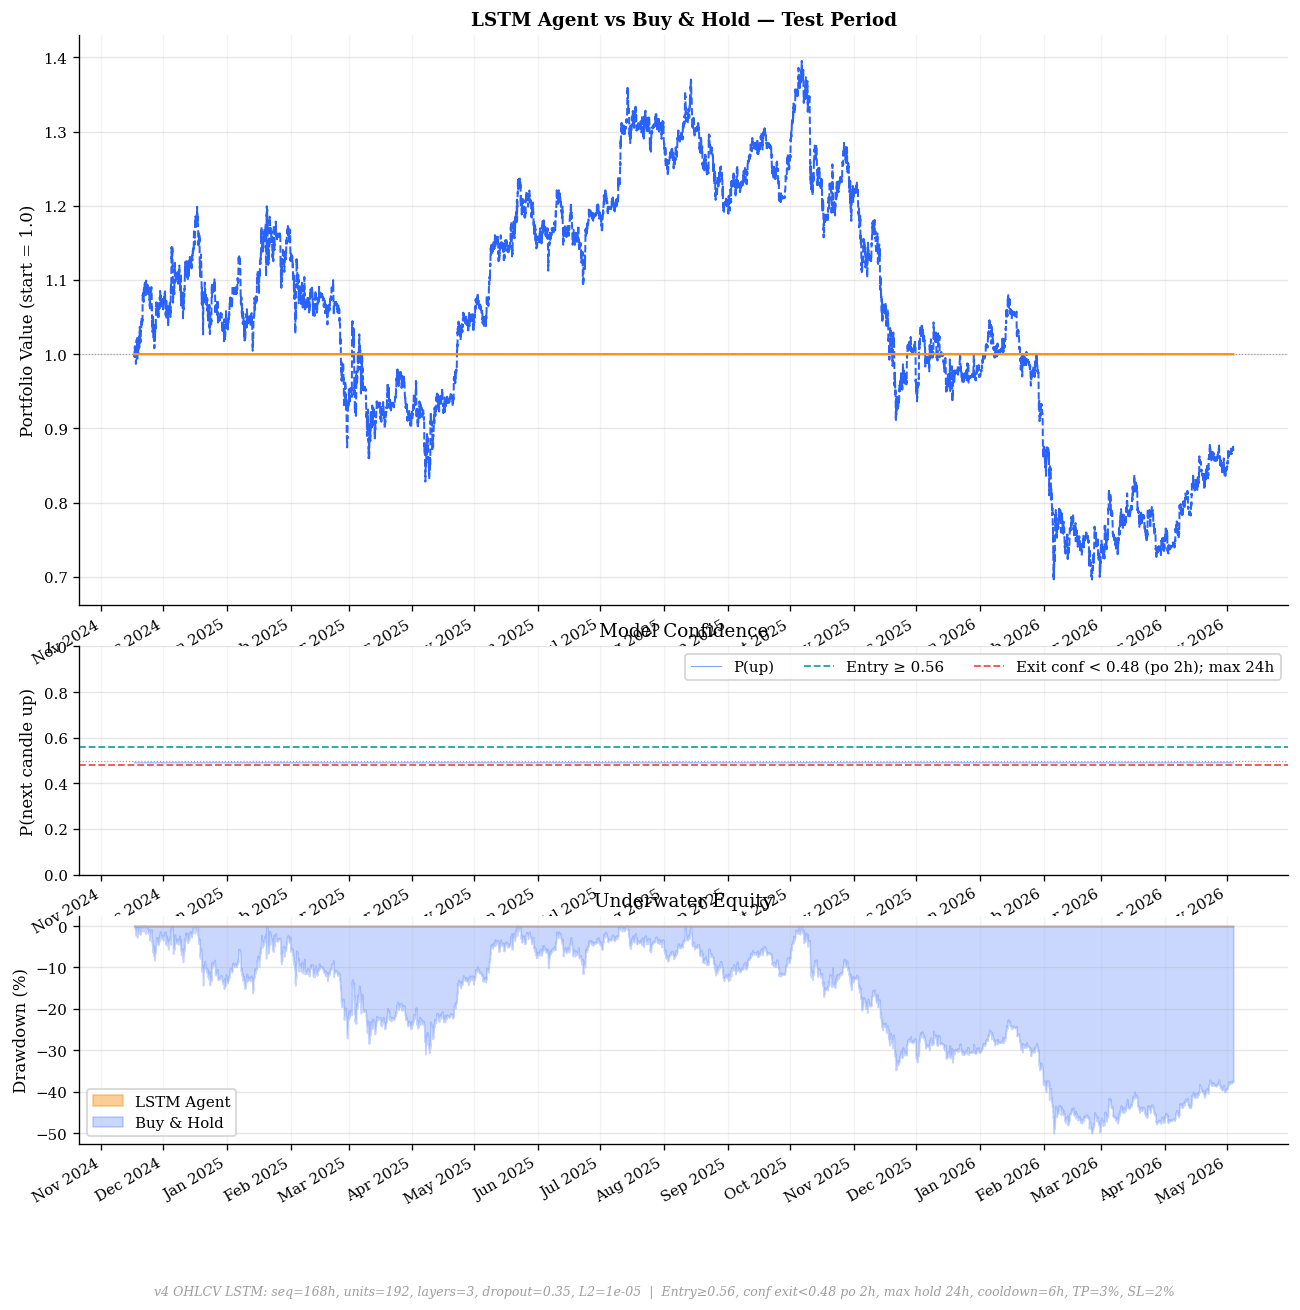

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(13, 12),
                         gridspec_kw={'height_ratios': [3, 1.2, 1.2], 'hspace': 0.12})

# ── Equity curves ─────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(signal_index, equity_arr, color=ACCENT, lw=1.4, label='LSTM Agent', zorder=3)
ax.plot(signal_index, bh_equity,  color=BLUE,   lw=1.2, ls='--', label='Buy & Hold', zorder=2)
ax.axhline(1.0, color=GREY, lw=0.7, ls=':')
if not trades_df.empty:
    eq_series = pd.Series(equity_arr, index=signal_index)
    for _, row in trades_df.iterrows():
        ev = eq_series.index.get_indexer([row['entry_time']], method='nearest')[0]
        xv = eq_series.index.get_indexer([row['exit_time']],  method='nearest')[0]
        ax.scatter(eq_series.index[ev], equity_arr[ev], marker='^', color=GREEN, s=35, zorder=5)
        ax.scatter(eq_series.index[xv], equity_arr[xv], marker='v', color=RED,   s=35, zorder=5)
    from matplotlib.lines import Line2D
    ax.legend(handles=[
        *ax.get_legend_handles_labels()[0][:2],
        Line2D([0],[0], marker='^', color='w', markerfacecolor=GREEN, markersize=8, label='Entry'),
        Line2D([0],[0], marker='v', color='w', markerfacecolor=RED,   markersize=8, label='Exit'),
    ], ncol=2)
ax.set_ylabel('Portfolio Value (start = 1.0)')
ax.set_title('LSTM Agent vs Buy & Hold — Test Period', fontweight='bold')
ax.grid(axis='y', alpha=0.3); ax.grid(axis='x', alpha=0.15)

# ── Confidence ────────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(signal_index, probs, color=BLUE, lw=0.6, alpha=0.6, label='P(up)')
ax.axhline(CONFIDENCE_THRESHOLD, color=GREEN, ls='--', lw=1.1,
           label=f'Entry ≥ {CONFIDENCE_THRESHOLD}')
ax.axhline(EXIT_THRESHOLD, color=RED, ls='--', lw=1.1,
           label=f'Exit conf < {EXIT_THRESHOLD} (po {MIN_HOLD_CANDLES}h); max {MAX_HOLD_CANDLES}h')
ax.axhline(0.5, color=GREY, ls=':', lw=0.7)
ax.set_ylim(0, 1); ax.set_ylabel('P(next candle up)')
ax.set_title('Model Confidence'); ax.legend(ncol=3)
ax.grid(axis='y', alpha=0.3); ax.grid(axis='x', alpha=0.15)

# ── Drawdown ──────────────────────────────────────────────────────────────────
ax = axes[2]
peak_l = np.maximum.accumulate(equity_arr)
peak_b = np.maximum.accumulate(bh_equity)
dd_l   = (equity_arr - peak_l) / (peak_l + 1e-12) * 100
dd_b   = (bh_equity  - peak_b) / (peak_b  + 1e-12) * 100
ax.fill_between(signal_index, dd_l, 0, color=ACCENT, alpha=0.45, label='LSTM Agent')
ax.fill_between(signal_index, dd_b, 0, color=BLUE,   alpha=0.25, label='Buy & Hold')
ax.set_ylabel('Drawdown (%)'); ax.set_title('Underwater Equity')
ax.legend(); ax.grid(axis='y', alpha=0.3); ax.grid(axis='x', alpha=0.15)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.text(0.5, 0.005,
    f'v4 OHLCV LSTM: seq={SEQ_LEN}h, units={LSTM_UNITS}, layers={NUM_LAYERS}, dropout={DROPOUT}, '
    f'L2={WEIGHT_DECAY}  |  '
    f'Entry≥{CONFIDENCE_THRESHOLD}, conf exit<{EXIT_THRESHOLD} po {MIN_HOLD_CANDLES}h, max hold {MAX_HOLD_CANDLES}h, '
    f'cooldown={COOLDOWN_CANDLES}h, TP={TAKE_PROFIT*100:.0f}%, SL={STOP_LOSS*100:.0f}%',
    ha='center', fontsize=7.5, color=GREY, style='italic')

fig.savefig(FIGURES_DIR / 'lstm_backtest_results_v4.png')
plt.show()


## 10. Trade log

In [13]:
if not trades_df.empty:
    trades_df['pnl_fmt'] = trades_df['pnl_pct'].apply(lambda x: f'{x*100:+.2f}%')
    display(trades_df[['entry_time','exit_time','hold_h','entry_px','exit_px','pnl_fmt','reason']])


In [14]:
# ── Percentyle (v4) pewności P(up) w czasie ───────────────────────────────────────
from IPython.display import display

conf = pd.Series(np.asarray(probs).ravel(), index=signal_index, name='P_up')

# Cały okres testowy (jeden rozkład)
static_levels = [1, 5, 10, 25, 50, 75, 90, 95, 99]
static_tbl = pd.DataFrame(
    {'percentyl_%': static_levels, 'P_up': [conf.quantile(p / 100.0) for p in static_levels]}
)
print('Percentyle P(up) — cały okres testowy')
display(static_tbl)

# Rolling: percentyle rozkładu P(up) w przesuwającym się oknie (jak zmienia się „kształt” szeregu)
ROLL_WINDOW = 336  # h (2 tygodnie przy 1h); np. 168 = 1 tydzień
min_periods = max(48, ROLL_WINDOW // 8)
roll_pct = pd.DataFrame({
    f'p{p}': conf.rolling(ROLL_WINDOW, min_periods=min_periods).quantile(p / 100.0)
    for p in (5, 10, 25, 50, 75, 90, 95)
})
print(f'Rolling percentyle P(up), okno={ROLL_WINDOW}h (pierwsze / ostatnie wiersze bez NaN):')
display(roll_pct.dropna().head(10))
display(roll_pct.dropna().tail(10))


Percentyle P(up) — cały okres testowy


,percentyl_%,P_up
0,1,0.489939
1,5,0.489939
2,10,0.489939
3,25,0.489939
4,50,0.489939
5,75,0.489939
6,90,0.489939
7,95,0.489939
8,99,0.489939


Rolling percentyle P(up), okno=336h (pierwsze / ostatnie wiersze bez NaN):


,p5,p10,p25,p50,p75,p90,p95
open_time,,,,,,,
2024-11-19 00:00:00,0.489939,0.489939,0.489939,0.489939,0.489939,0.489939,0.489939
2024-11-19 01:00:00,0.489939,0.489939,0.489939,0.489939,0.489939,0.489939,0.489939
2024-11-19 02:00:00,0.489939,0.489939,0.489939,0.489939,0.489939,0.489939,0.489939
2024-11-19 03:00:00,0.489939,0.489939,0.489939,0.489939,0.489939,0.489939,0.489939
2024-11-19 04:00:00,0.489939,0.489939,0.489939,0.489939,0.489939,0.489939,0.489939
2024-11-19 05:00:00,0.489939,0.489939,0.489939,0.489939,0.489939,0.489939,0.489939
2024-11-19 06:00:00,0.489939,0.489939,0.489939,0.489939,0.489939,0.489939,0.489939
2024-11-19 07:00:00,0.489939,0.489939,0.489939,0.489939,0.489939,0.489939,0.489939
2024-11-19 08:00:00,0.489939,0.489939,0.489939,0.489939,0.489939,0.489939,0.489939


,p5,p10,p25,p50,p75,p90,p95
open_time,,,,,,,
2026-05-03 15:00:00,0.489939,0.489939,0.489939,0.489939,0.489939,0.489939,0.489939
2026-05-03 16:00:00,0.489939,0.489939,0.489939,0.489939,0.489939,0.489939,0.489939
2026-05-03 17:00:00,0.489939,0.489939,0.489939,0.489939,0.489939,0.489939,0.489939
2026-05-03 18:00:00,0.489939,0.489939,0.489939,0.489939,0.489939,0.489939,0.489939
2026-05-03 19:00:00,0.489939,0.489939,0.489939,0.489939,0.489939,0.489939,0.489939
2026-05-03 20:00:00,0.489939,0.489939,0.489939,0.489939,0.489939,0.489939,0.489939
2026-05-03 21:00:00,0.489939,0.489939,0.489939,0.489939,0.489939,0.489939,0.489939
2026-05-03 22:00:00,0.489939,0.489939,0.489939,0.489939,0.489939,0.489939,0.489939
2026-05-03 23:00:00,0.489939,0.489939,0.489939,0.489939,0.489939,0.489939,0.489939
